# Matplotlib Exercises — Heart Disease Dataset

These exercises practise the matplotlib techniques from the **Introduction to Matplotlib** notebook, applied to the heart-disease dataset (303 patients).

You'll cover: plotting from a pandas DataFrame, scatter plots coloured by `target`, histograms, subplots (including a shared x-axis), the `over_50` analysis pattern, mean lines (`axhline`), colormaps (`cmap`), axis limits (`xlim`/`ylim`), and saving figures.

**The columns:**

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 0 = female, 1 = male |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure |
| `chol` | Serum cholesterol (mg/dl) |
| `thalach` | Maximum heart rate achieved |
| `target` | 1 = has heart disease, 0 = no heart disease |

**Instructions:** Solve each exercise in the empty cell below its prompt. Full answers are in the separate notebook **`matplotlib_exercises_solutions.ipynb`** — try each one yourself first.

## 0. Setup

**Exercise 0.** Import `matplotlib.pyplot` as `plt` and `pandas` as `pd`, enable inline plotting, and read `../data/heart-disease.csv` into a DataFrame called `heart_disease`. Show the first 5 rows.

In [1]:
# Your code here
import pandas as pd 
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\HP\Downloads\heart-disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1. Plotting directly from a pandas DataFrame

**Exercise 1.** Plot a **histogram** of the `age` column directly from pandas using `.plot.hist()` with 50 bins. What does this tell you about the spread of ages?

(array([ 1.,  0.,  0.,  0.,  0.,  2.,  4.,  0.,  2.,  3.,  4.,  3., 10.,
         8.,  8., 11.,  8.,  7.,  5.,  7.,  5.,  7., 12., 13.,  0.,  8.,
        16.,  8., 11., 17., 19., 14., 11.,  8., 11.,  9., 10.,  8.,  7.,
         9.,  4.,  3.,  4.,  3.,  0.,  0.,  1.,  0.,  1.,  1.]),
 array([29.  , 29.96, 30.92, 31.88, 32.84, 33.8 , 34.76, 35.72, 36.68,
        37.64, 38.6 , 39.56, 40.52, 41.48, 42.44, 43.4 , 44.36, 45.32,
        46.28, 47.24, 48.2 , 49.16, 50.12, 51.08, 52.04, 53.  , 53.96,
        54.92, 55.88, 56.84, 57.8 , 58.76, 59.72, 60.68, 61.64, 62.6 ,
        63.56, 64.52, 65.48, 66.44, 67.4 , 68.36, 69.32, 70.28, 71.24,
        72.2 , 73.16, 74.12, 75.08, 76.04, 77.  ]),
 <BarContainer object of 50 artists>)

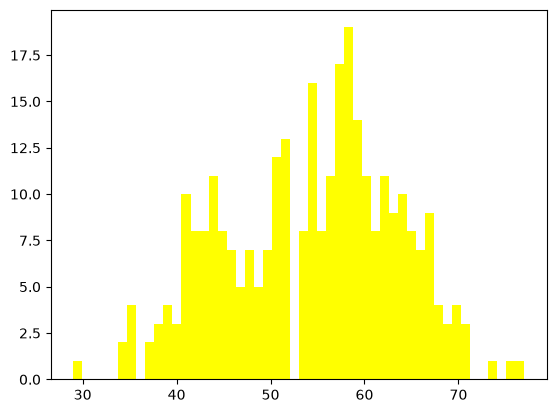

In [ ]:
# Your code here
fig,ax=plt.subplots()
ax.hist(df["age"],color="yellow",bins=50)
#it tells us that people with 59 years old have the highest distribution

**Exercise 2.** Plot a histogram of **every column at once** by calling `.plot.hist()` on the whole DataFrame with `subplots=True` and `figsize=(5, 20)`.

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
      dtype=object)

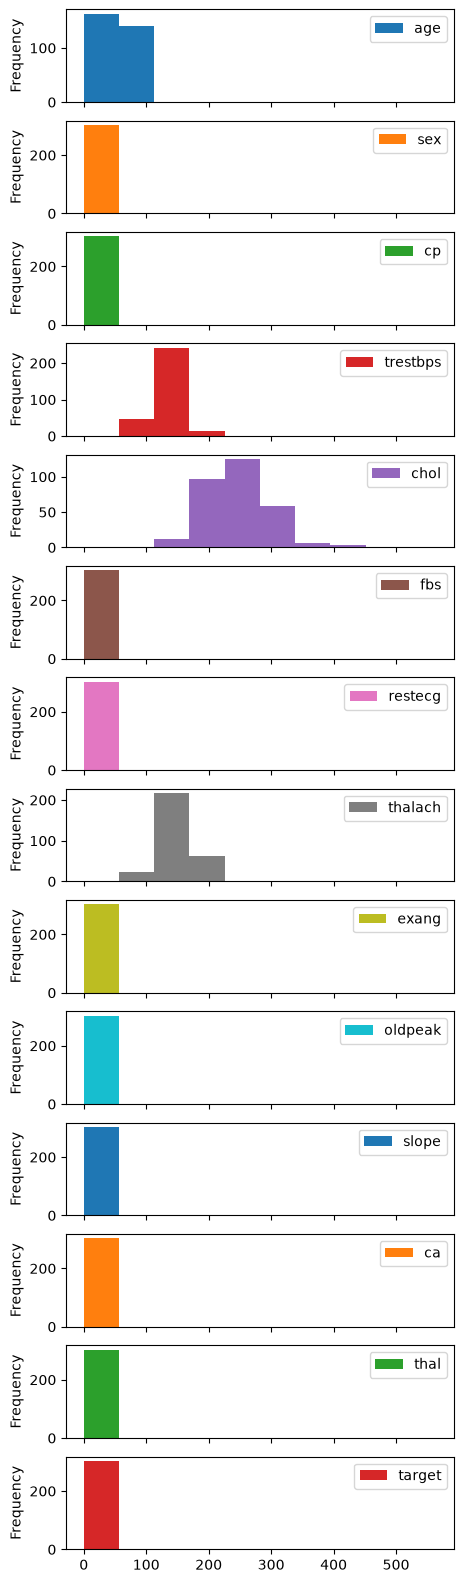

In [11]:
# Your code here
df.plot.hist(subplots=True, figsize=(5, 20))

## 2. Analysing patients over 50

**Exercise 3.** Create a new DataFrame called `over_50` containing only the patients **older than 50** (`age > 50`). How many rows does it have?

In [12]:
# Your code here
over_50=df[df["age"]>50]
over_50.shape

(208, 14)

**Exercise 4.** Using the object-oriented API (`fig, ax = plt.subplots(figsize=(10, 6))`), make a **scatter plot** of `over_50`'s `age` (x) vs `chol` (y), **colouring the points by the `target` column** (`c=over_50["target"]`).

Add a title "Heart Disease and Cholesterol Levels", axis labels, and a legend built with `ax.legend(*scatter.legend_elements(), title="Target")`.

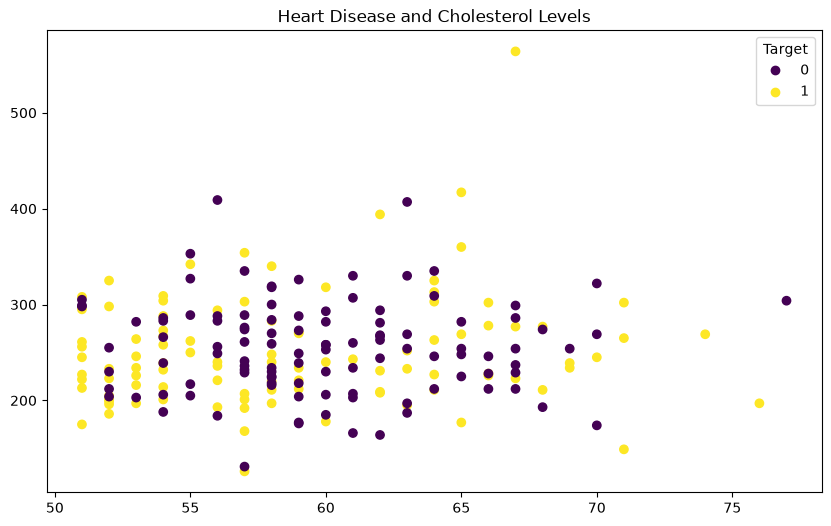

In [24]:
# Your code here
fig,ax=plt.subplots(figsize=(10,6))
sc=ax.scatter(over_50["age"],over_50["chol"],c=over_50["target"],label="over_50")
ax.legend(*sc.legend_elements(),title="Target")
plt.title("Heart Disease and Cholesterol Levels")
plt.show()

**Exercise 5.** Recreate the scatter plot from Exercise 4, then add a **horizontal dashed line** showing the **mean cholesterol** using `ax.axhline(over_50["chol"].mean(), linestyle="--")`.

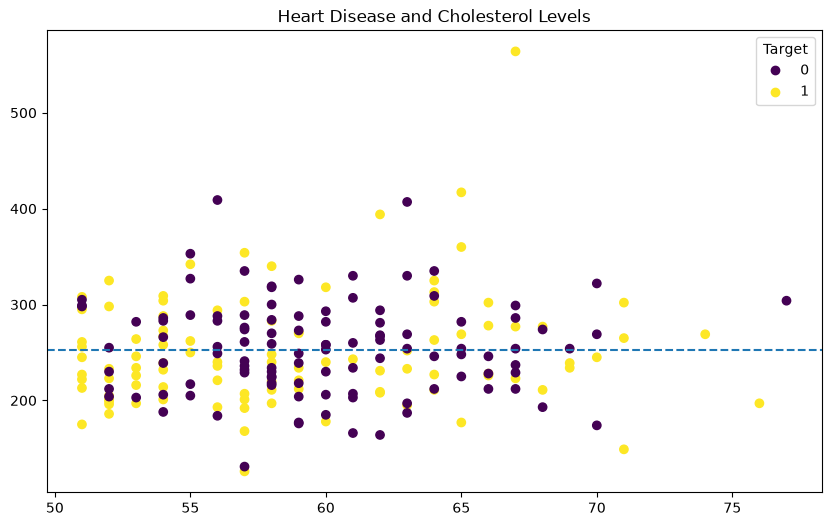

In [25]:
# Your code here
fig,ax=plt.subplots(figsize=(10,6))
sc=ax.scatter(over_50["age"],over_50["chol"],c=over_50["target"],label="over_50")
ax.axhline(over_50["chol"].mean(),linestyle="--")
plt.legend(*sc.legend_elements(),title="Target")
plt.title("Heart Disease and Cholesterol Levels")
plt.show()

## 3. Multiple Axes on one Figure

**Exercise 6.** Create a Figure with **2 rows and 1 column** of Axes that **share the x-axis** (`nrows=2, ncols=1, sharex=True, figsize=(10, 8)`):

- top Axis (`ax0`): scatter of `over_50` `age` vs `chol`, coloured by `target`
- bottom Axis (`ax1`): scatter of `over_50` `age` vs `thalach`, coloured by `target`

Give each Axis a title and y-label, and a legend.

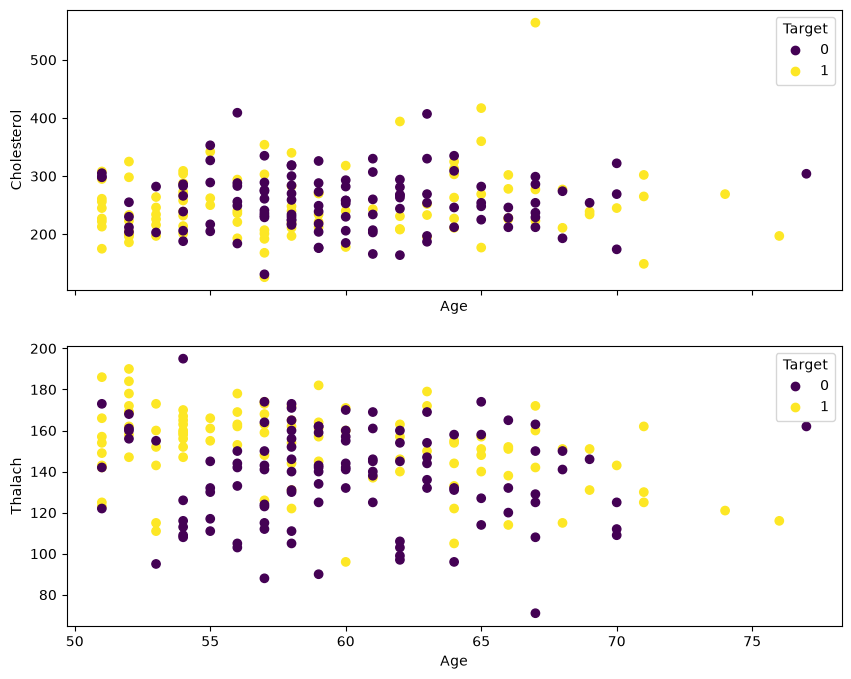

In [27]:
# Your code here
fig,(ax0,ax1)=plt.subplots(nrows=2,ncols=1,sharex=True,figsize=(10,8))
sc0=ax0.scatter(over_50["age"],over_50["chol"],c=over_50["target"])
ax0.set_xlabel("Age")
ax0.set_ylabel("Cholesterol")
ax0.legend(*sc0.legend_elements(),title="Target")
sc1=ax1.scatter(over_50["age"],over_50["thalach"],c=over_50["target"])
ax1.set_xlabel("Age")
ax1.set_ylabel("Thalach")
ax1.legend(*sc1.legend_elements(),title="Target")

## 4. Customizing your plots

**Exercise 7.** Redraw the `over_50` `age` vs `chol` scatter, but change the **colormap** to `"winter"` (pass `cmap="winter"` to `ax.scatter`). Add a red mean line with `ax.axhline(..., color="r")`.

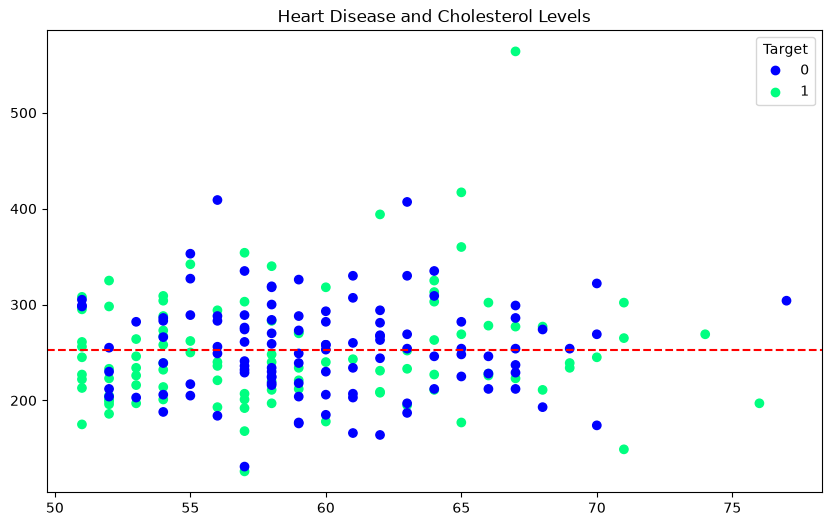

In [28]:
# Your code here
fig,ax=plt.subplots(figsize=(10,6))
sc=ax.scatter(over_50["age"],over_50["chol"],c=over_50["target"],label="over_50",cmap="winter")
ax.axhline(over_50["chol"].mean(),linestyle="--",color="r")
plt.legend(*sc.legend_elements(),title="Target")
plt.title("Heart Disease and Cholesterol Levels")
plt.show()

**Exercise 8.** Redraw the same scatter plot, but set the **axis limits** so the x-axis runs from 50 to 80 and the y-axis from 100 to 600 (use `ax.set(xlim=[50, 80], ylim=[100, 600])`).

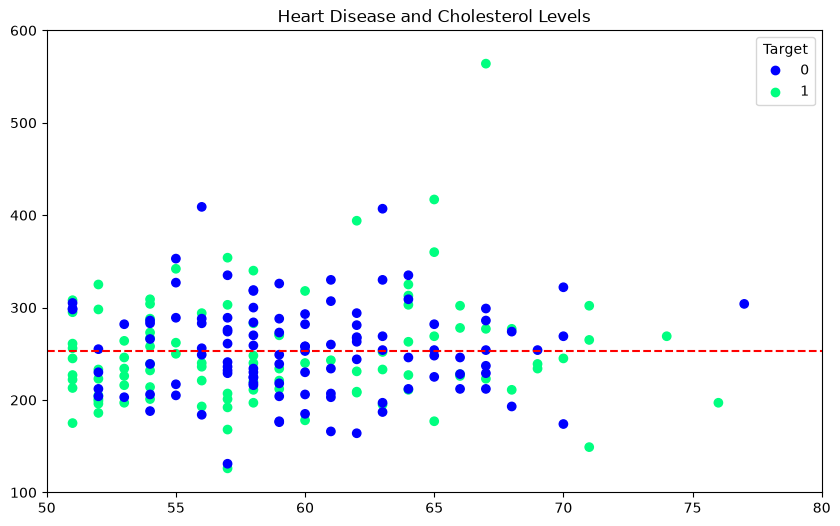

In [29]:
# Your code here
fig,ax=plt.subplots(figsize=(10,6))
sc=ax.scatter(over_50["age"],over_50["chol"],c=over_50["target"],label="over_50",cmap="winter")
ax.axhline(over_50["chol"].mean(),linestyle="--",color="r")
ax.set(xlim=[50,80],ylim=[100,600])
plt.legend(*sc.legend_elements(),title="Target")
plt.title("Heart Disease and Cholesterol Levels")
plt.show()

**Exercise 9.** Try a **built-in style**: call `plt.style.use("seaborn-v0_8")` (or `"ggplot"`), then redraw the `age` vs `chol` scatter coloured by `target`. (List options with `plt.style.available`. Reset afterwards with `plt.style.use("default")`.)

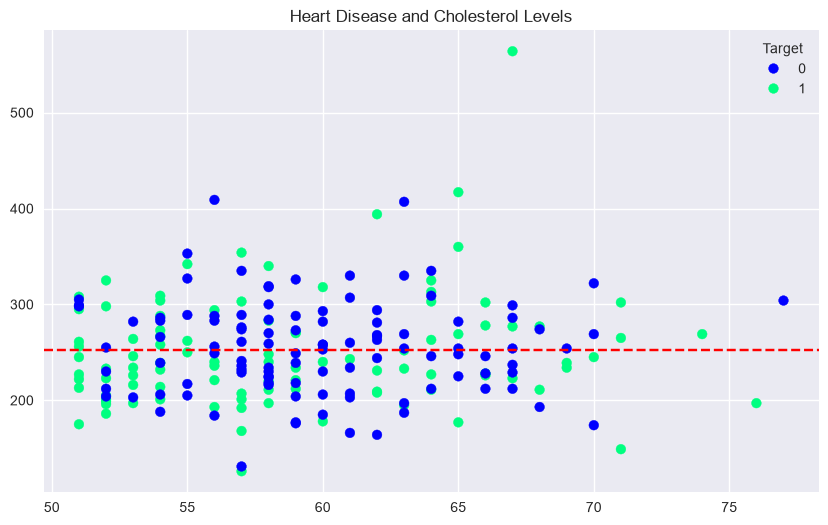

In [31]:
# Your code here
plt.style.use("seaborn-v0_8")
fig,ax=plt.subplots(figsize=(10,6))
sc=ax.scatter(over_50["age"],over_50["chol"],c=over_50["target"],label="over_50",cmap="winter")
ax.axhline(over_50["chol"].mean(),linestyle="--",color="r")
plt.legend(*sc.legend_elements(),title="Target")
plt.title("Heart Disease and Cholesterol Levels")
plt.show()
plt.style.use("default")

## 5. Saving plots

**Exercise 10.** Build any plot you like from the data, then **save the figure** to `heart-disease-analysis.png` using `fig.savefig(fname=..., dpi=100)`.

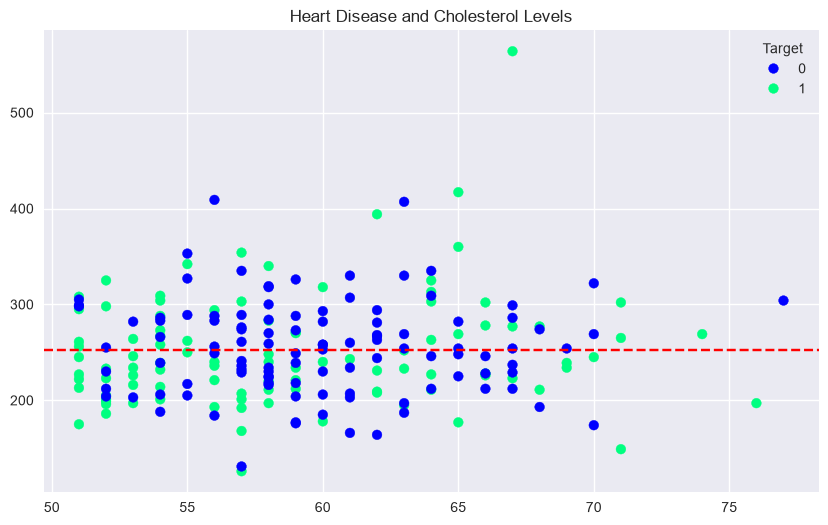

In [32]:
# Your code here
plt.style.use("seaborn-v0_8")
fig,ax=plt.subplots(figsize=(10,6))
sc=ax.scatter(over_50["age"],over_50["chol"],c=over_50["target"],label="over_50",cmap="winter")
ax.axhline(over_50["chol"].mean(),linestyle="--",color="r")
plt.legend(*sc.legend_elements(),title="Target")
plt.title("Heart Disease and Cholesterol Levels")
plt.show()
plt.style.use("default")
fig.savefig(fname="age_vs_chol.jpg",dpi=100)

## 🏆 Challenge Exercises

1. Build the **2-row shared-x dashboard** (`age` vs `chol` on top, `age` vs `thalach` below) but use `cmap="winter"` on both, add a **mean line** to each, and set `xlim=[50, 80]`.
2. Add a shared figure title to the dashboard with `fig.suptitle("Heart Disease Analysis (patients over 50)")`.
3. Save the finished dashboard to `heart-disease-analysis.png` with `dpi=100` and `bbox_inches="tight"`.

In [ ]:
# Your challenge code here
